In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = pd.read_csv("customer_support_tickets.csv")

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


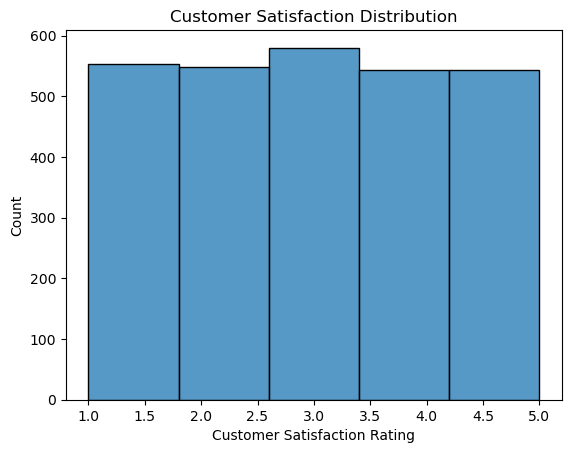

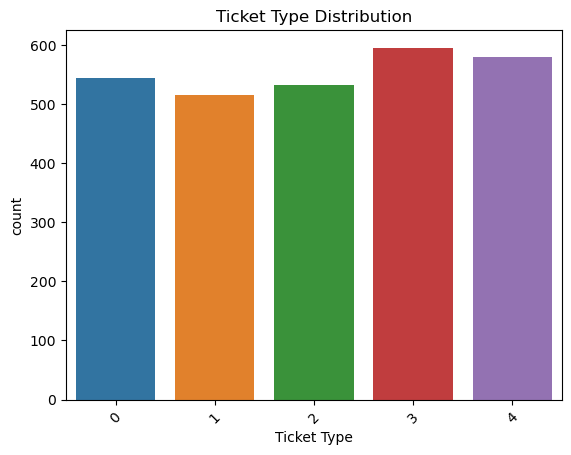

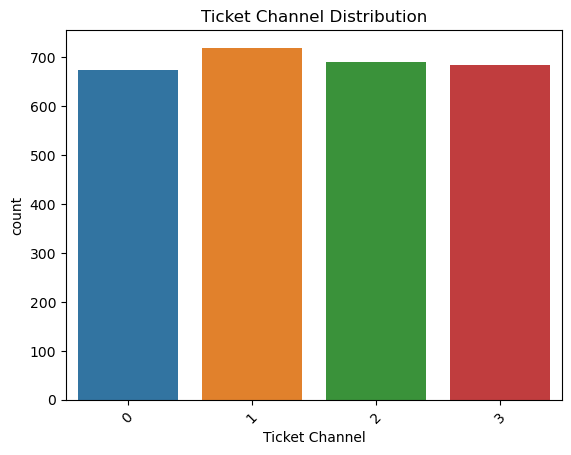

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


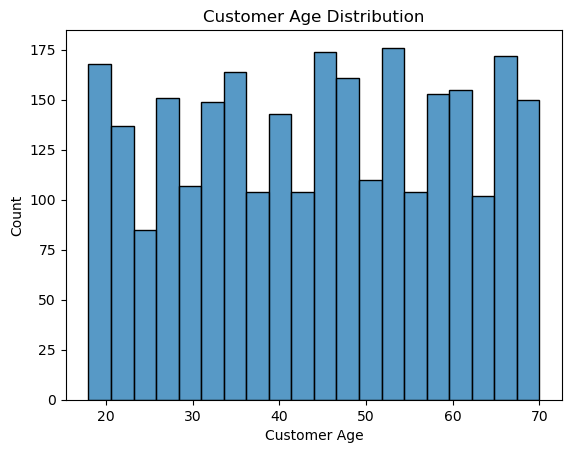

In [11]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 2. LOAD DATASET
# =========================
data = pd.read_csv("customer_support_tickets.csv")

print(data.head())

# =========================
# 3. DATA CLEANING
# =========================

# Remove rows where target is missing
data = data.dropna(subset=['Customer Satisfaction Rating'])

# Fill missing values
data.ffill(inplace=True)

# Convert date
data['Date of Purchase'] = pd.to_datetime(data['Date of Purchase'], errors='coerce')

# =========================
# 4. ENCODING
# =========================
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])

# =========================
# 5. SPLIT DATA
# =========================
X = data.drop(['Customer Satisfaction Rating', 'Date of Purchase'], axis=1)
y = data['Customer Satisfaction Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# =========================
# 6. SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 7. MODEL
# =========================
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# =========================
# 8. PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# 9. EVALUATION
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =========================
# 10. VISUALIZATION
# =========================

# Satisfaction Distribution
sns.histplot(data['Customer Satisfaction Rating'], bins=5)
plt.title("Customer Satisfaction Distribution")
plt.show()

# Ticket Type
sns.countplot(x='Ticket Type', data=data)
plt.xticks(rotation=45)
plt.title("Ticket Type Distribution")
plt.show()

# Ticket Channel
sns.countplot(x='Ticket Channel', data=data)
plt.xticks(rotation=45)
plt.title("Ticket Channel Distribution")
plt.show()

# Age Distribution
sns.histplot(data['Customer Age'], bins=20)
plt.title("Customer Age Distribution")
plt.show()

In [10]:
X_train = scaler.fit_transform(X_train)